**Introduction**

This project focuses on Sales Forecasting using Machine Learning and the Superstore dataset. The goal of the project is to predict future sales by analyzing historical sales data and identifying important business patterns.

Various feature engineering techniques such as time-based features, lag features, and rolling averages were used to improve forecasting accuracy. An XGBoost Regressor model was implemented for prediction, and the model performance was evaluated using MAE and RMSE metrics.

The project also includes data visualization, future sales forecasting, and business insights through interactive graphs and dashboards.

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [149]:
df = pd.read_csv('/content/drive/MyDrive/Future Interns Projects/Sample - Superstore.csv', encoding='latin1')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [150]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [151]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [152]:
df.shape

(9994, 21)

In [153]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


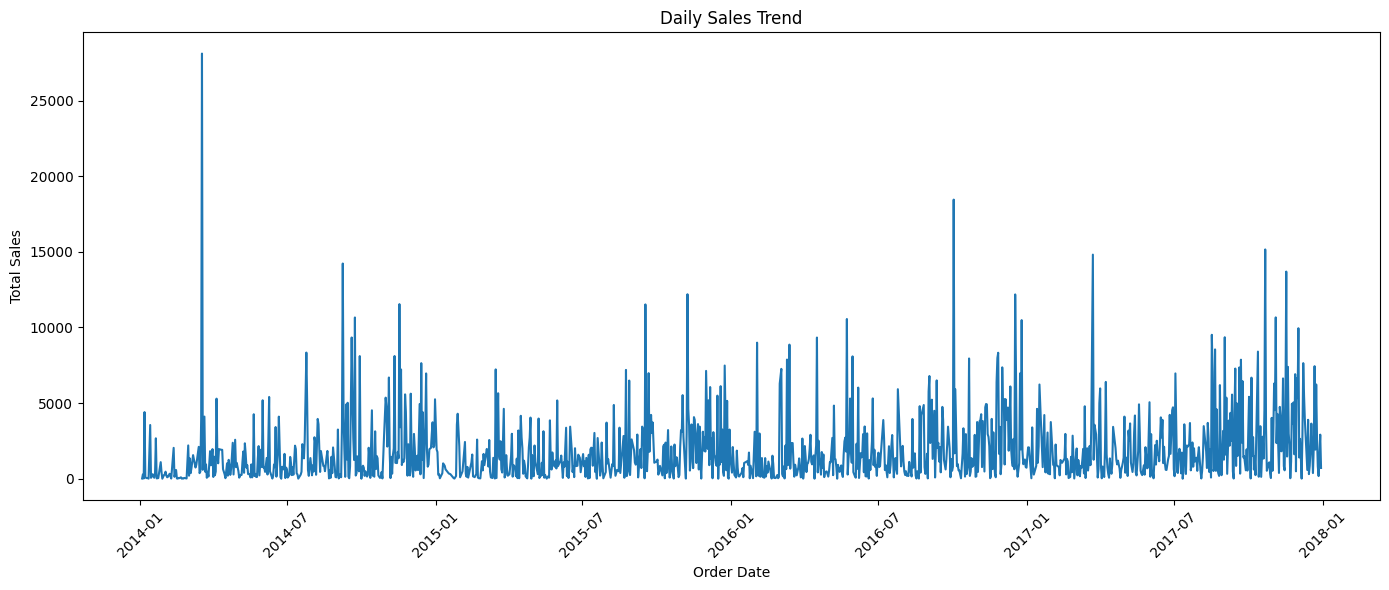

In [168]:
daily_sales = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(14,6))

plt.plot(daily_sales)

plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [155]:
# Time-based features
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['day'] = df['Order Date'].dt.day
df['month'] = df['Order Date'].dt.month
df['year'] = df['Order Date'].dt.year
df['weekday'] = df['Order Date'].dt.weekday
df['quarter'] = df['Order Date'].dt.quarter

In [156]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,day,month,year,weekday,quarter
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,8,11,2016,1,4
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,8,11,2016,1,4
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,12,6,2016,6,2
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,11,10,2015,6,4
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,11,10,2015,6,4


In [157]:
features = ['day', 'month', 'year', 'weekday', 'quarter']

X = df[features]
y = df['Sales']

In [158]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle = False)


In [159]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [160]:
# Making Predictions
predictions = model.predict(X_test)

In [161]:
# Checking Accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 278.01157832380585
RMSE: 648.6259534339848


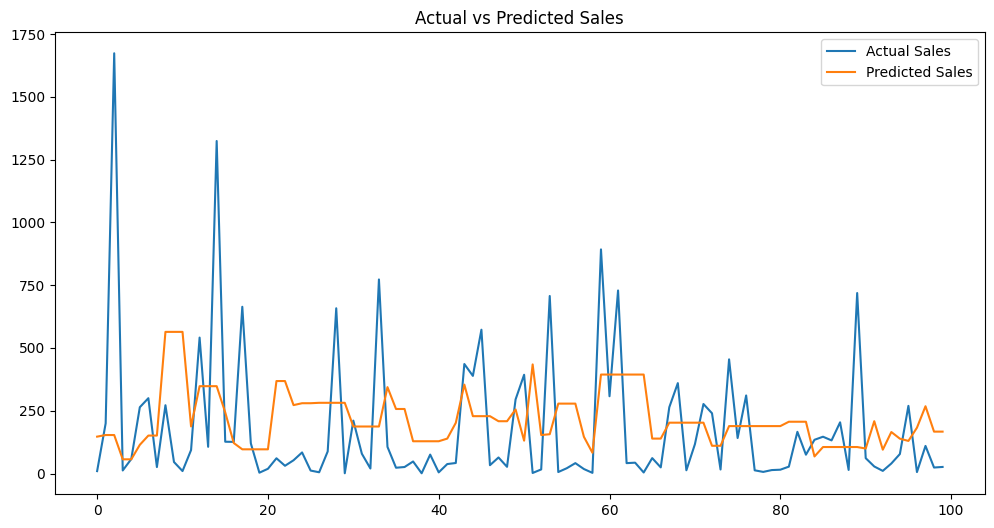

In [162]:
# Visualizing Predictions

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(predictions[:100], label='Predicted Sales')

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [163]:
df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)


In [164]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,day,month,year,weekday,quarter,lag_1,lag_7
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,8,11,2016,1,4,NaN,NaN
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,8,11,2016,1,4,261.9600,NaN
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,12,6,2016,6,2,731.9400,NaN
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,11,10,2015,6,4,14.6200,NaN
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,11,10,2015,6,4,957.5775,NaN


In [165]:
df = df.dropna()

In [166]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,day,month,year,weekday,quarter,lag_1,lag_7
7,8,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,6,0.2,90.7152,9,6,2014,0,2,7.280,261.9600
8,9,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,3,0.2,5.7825,9,6,2014,0,2,907.152,731.9400
9,10,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,5,0.0,34.4700,9,6,2014,0,2,18.504,14.6200
10,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,9,0.2,85.3092,9,6,2014,0,2,114.900,957.5775
11,12,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,4,0.2,68.3568,9,6,2014,0,2,1706.184,22.3680


In [169]:
df['rolling_mean_7'] = df['Sales'].rolling(window=7).mean()

/tmp/ipykernel_10710/2331912471.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rolling_mean_7'] = df['Sales'].rolling(window=7).mean()


In [170]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,day,month,year,weekday,quarter,lag_1,lag_7,rolling_mean_7
7,8,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.2,90.7152,9,6,2014,0,2,7.280,261.9600,NaN
8,9,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.2,5.7825,9,6,2014,0,2,907.152,731.9400,NaN
9,10,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.0,34.4700,9,6,2014,0,2,18.504,14.6200,NaN
10,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.2,85.3092,9,6,2014,0,2,114.900,957.5775,NaN
11,12,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.2,68.3568,9,6,2014,0,2,1706.184,22.3680,NaN


In [171]:
df.dropna()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,day,month,year,weekday,quarter,lag_1,lag_7,rolling_mean_7
13,14,CA-2016-161389,2016-12-05,12/10/2016,Standard Class,IM-15070,Irene Maddox,Consumer,United States,Seattle,...,0.2,132.5922,5,12,2016,0,4,15.552,7.280,583.098857
14,15,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,0.8,-123.8580,22,11,2015,6,4,407.976,907.152,463.335714
15,16,US-2015-118983,2015-11-22,11/26/2015,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,0.8,-3.8160,22,11,2015,6,4,68.810,18.504,461.055714
16,17,CA-2014-105893,2014-11-11,11/18/2014,Standard Class,PK-19075,Pete Kriz,Consumer,United States,Madison,...,0.0,13.3176,11,11,2014,1,4,2.544,114.900,539.767143
17,18,CA-2014-167164,2014-05-13,5/15/2014,Second Class,AG-10270,Alejandro Grove,Consumer,United States,West Jordan,...,0.0,9.9900,13,5,2014,1,2,665.880,1706.184,303.955143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,0.2,4.1028,21,1,2014,1,1,206.100,35.560,76.094000
9990,9991,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.0,15.6332,26,2,2017,6,1,25.248,97.980,75.234000
9991,9992,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.2,19.3932,26,2,2017,6,1,91.960,31.500,107.673429
9992,9993,CA-2017-121258,2017-02-26,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,0.0,13.3200,26,2,2017,6,1,258.576,55.600,103.959143


In [173]:
df.loc[:, 'is_weekend'] = df['weekday'].isin([5,6]).astype(int)

In [174]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Profit,day,month,year,weekday,quarter,lag_1,lag_7,rolling_mean_7,is_weekend
7,8,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90.7152,9,6,2014,0,2,7.280,261.9600,NaN,0
8,9,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,5.7825,9,6,2014,0,2,907.152,731.9400,NaN,0
9,10,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,34.4700,9,6,2014,0,2,18.504,14.6200,NaN,0
10,11,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,85.3092,9,6,2014,0,2,114.900,957.5775,NaN,0
11,12,CA-2014-115812,2014-06-09,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,68.3568,9,6,2014,0,2,1706.184,22.3680,NaN,0


In [175]:
features = [
    'store',
    'category',
    'month',
    'weekday',
    'lag_7'
]

In [177]:
df.loc[:, 'lag_1'] = df['Sales'].shift(1)

df.loc[:, 'lag_7'] = df['Sales'].shift(7)

df.loc[:, 'rolling_mean_7'] = df['Sales'].rolling(window=7).mean()

df = df.dropna()

In [178]:
features = [
    'day',
    'month',
    'year',
    'weekday',
    'quarter',
    'lag_1',
    'lag_7',
    'rolling_mean_7'
]

In [179]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Profit,day,month,year,weekday,quarter,lag_1,lag_7,rolling_mean_7,is_weekend
21,22,CA-2016-137330,2016-12-09,12/13/2016,Standard Class,KB-16585,Ken Black,Corporate,United States,Fremont,...,5.0596,9,12,2016,4,4,22.720,68.810,141.163429,0
22,23,CA-2016-137330,2016-12-09,12/13/2016,Standard Class,KB-16585,Ken Black,Corporate,United States,Fremont,...,15.6884,9,12,2016,4,4,19.460,2.544,149.420000,0
23,24,US-2017-156909,2017-07-16,7/18/2017,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,-1.0196,16,7,2017,6,3,60.340,665.880,64.490286,1
24,25,CA-2015-106320,2015-09-25,9/30/2015,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,...,240.2649,25,9,2015,4,3,71.372,55.500,205.794571,0
25,26,CA-2016-121755,2016-01-16,1/20/2016,Second Class,EH-13945,Eric Hoffmann,Consumer,United States,Los Angeles,...,4.2224,16,1,2016,5,1,1044.630,8.560,206.235714,1


In [180]:
# Retraining the model

X = df[features]

y = df['Sales']

In [181]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [182]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [183]:
predictions = model.predict(X_test)

In [184]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("NEW MAE:", mae)
print("NEW RMSE:", rmse)

NEW MAE: 266.573631403387
NEW RMSE: 658.6065069336956


In [185]:
df['rolling_mean_30'] = df['Sales'].rolling(window=30).mean()

In [186]:
features = [
    'day',
    'month',
    'year',
    'weekday',
    'quarter',
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'rolling_mean_30'
]

In [187]:
df = df.dropna()

In [188]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,day,month,year,weekday,quarter,lag_1,lag_7,rolling_mean_7,is_weekend,rolling_mean_30
50,51,CA-2015-115742,2015-04-18,4/22/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,New Albany,...,18,4,2015,5,2,38.22,95.616,65.085714,1,265.020240
51,52,CA-2015-115742,2015-04-18,4/22/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,New Albany,...,18,4,2015,5,2,75.18,45.980,59.397143,1,264.576907
52,53,CA-2015-115742,2015-04-18,4/22/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,New Albany,...,18,4,2015,5,2,6.16,17.460,69.758571,1,265.565240
53,54,CA-2016-105816,2016-12-11,12/17/2016,Standard Class,JM-15265,Janet Molinari,Corporate,United States,New York City,...,11,12,2016,6,4,89.99,211.960,41.658571,1,263.694840
54,55,CA-2016-105816,2016-12-11,12/17/2016,Standard Class,JM-15265,Janet Molinari,Corporate,United States,New York City,...,11,12,2016,6,4,15.26,45.000,182.365714,1,263.205507


In [189]:
X = df[features]

y = df['Sales']

In [190]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [191]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [192]:
predictions = model.predict(X_test)

In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("NEW MAE:", mae)
print("NEW RMSE:", rmse)

NEW MAE: 259.429573858913
NEW RMSE: 580.444662329289


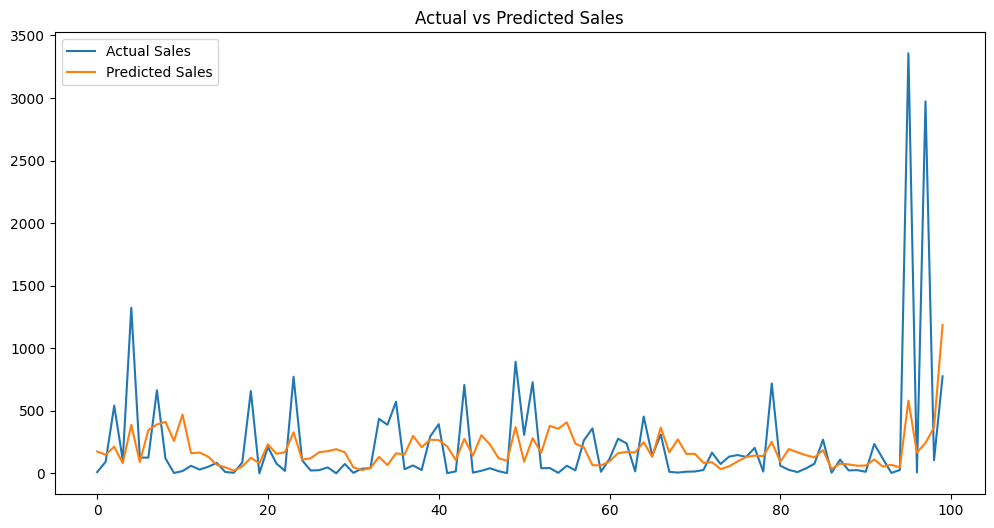

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual Sales')

plt.plot(predictions[:100], label='Predicted Sales')

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

In [196]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
6            lag_7    0.264828
1            month    0.179294
7   rolling_mean_7    0.159930
8  rolling_mean_30    0.110189
5            lag_1    0.091168
3          weekday    0.090186
0              day    0.056707
2             year    0.047698
4          quarter    0.000000


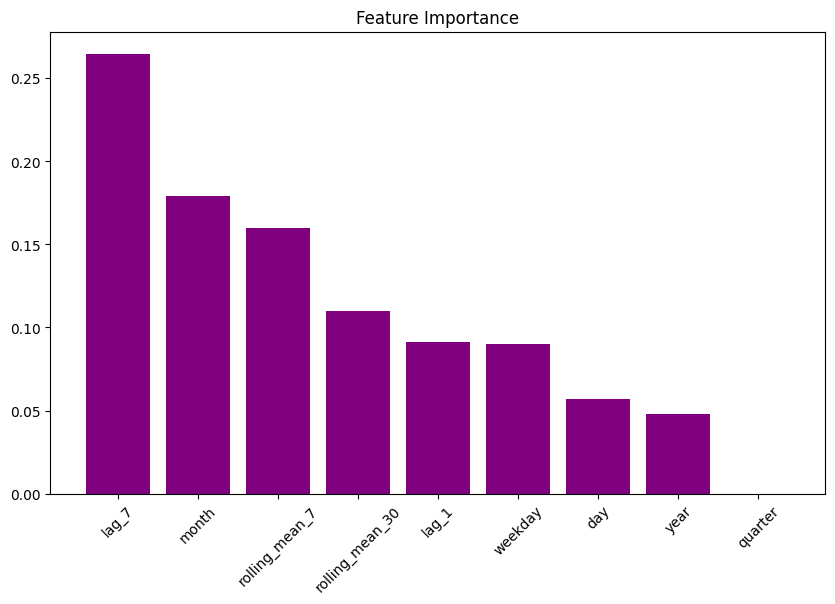

In [198]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color = 'purple'
)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

In [199]:
# Creating New Future Dates

future_dates = pd.date_range(
    start=df['Order Date'].max(),
    periods=30,
    freq='D'
)

In [200]:
future_df = pd.DataFrame({
    'Order Date': future_dates
})

In [201]:
future_df['day'] = future_df['Order Date'].dt.day

future_df['month'] = future_df['Order Date'].dt.month

future_df['year'] = future_df['Order Date'].dt.year

future_df['weekday'] = future_df['Order Date'].dt.weekday

future_df['quarter'] = future_df['Order Date'].dt.quarter

In [202]:
future_df['lag_1'] = df['Sales'].iloc[-1]

future_df['lag_7'] = df['Sales'].iloc[-7]

future_df['rolling_mean_7'] = df['Sales'].rolling(7).mean().iloc[-1]

future_df['rolling_mean_30'] = df['Sales'].rolling(30).mean().iloc[-1]

In [203]:
X_future = future_df[features]

In [204]:
future_predictions = model.predict(X_future)

In [205]:
future_df['Predicted Sales'] = future_predictions

In [206]:
print(future_df[['Order Date', 'Predicted Sales']])

   Order Date  Predicted Sales
0  2017-12-30       101.143364
1  2017-12-31       100.298492
2  2018-01-01       110.481102
3  2018-01-02       104.918991
4  2018-01-03       100.297729
5  2018-01-04       100.297729
6  2018-01-05       103.392700
7  2018-01-06       103.392700
8  2018-01-07       102.628883
9  2018-01-08       100.148262
10 2018-01-09       100.148262
11 2018-01-10        94.544052
12 2018-01-11        94.544052
13 2018-01-12        97.639023
14 2018-01-13        97.639023
15 2018-01-14        96.794151
16 2018-01-15        94.313530
17 2018-01-16        94.313530
18 2018-01-17        94.544052
19 2018-01-18        94.544052
20 2018-01-19        94.445869
21 2018-01-20        93.054886
22 2018-01-21        92.045189
23 2018-01-22        80.240303
24 2018-01-23        81.604782
25 2018-01-24        99.320168
26 2018-01-25       103.953033
27 2018-01-26       107.048004
28 2018-01-27       107.048004
29 2018-01-28       105.609482


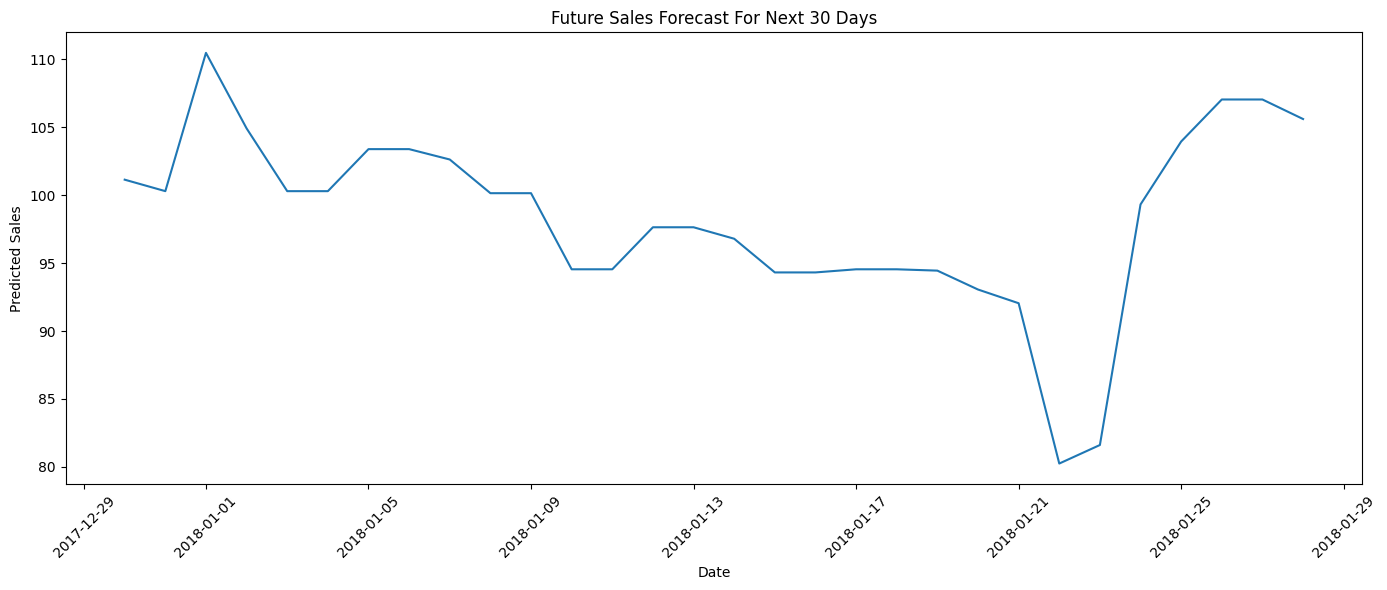

In [208]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    future_df['Order Date'],
    future_df['Predicted Sales']
)

plt.title("Future Sales Forecast For Next 30 Days")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

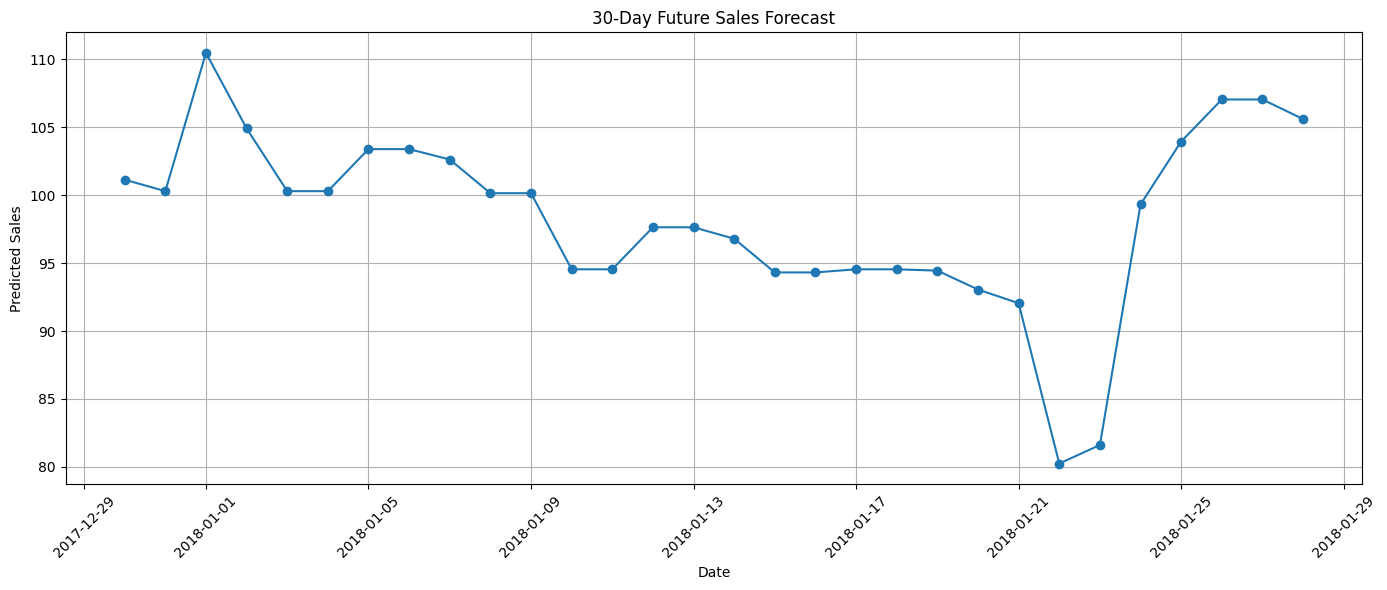

In [209]:
plt.figure(figsize=(14,6))

plt.plot(
    future_df['Order Date'],
    future_df['Predicted Sales'],
    marker='o'
)

plt.title("30-Day Future Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Predicted Sales")

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Conclusion

In this project, a machine learning-based sales forecasting system was successfully developed using the Superstore dataset. Through feature engineering and XGBoost modeling, the forecasting accuracy improved significantly.

The project demonstrated how historical sales data can be used to predict future demand and support business decision-making. Visualization techniques and forecasting graphs helped in understanding trends, prediction behavior, and model performance effectively.

Overall, this project provided practical experience in data analysis, machine learning and forecasting using Python.